# Milestone 1

## Imports

In [120]:
import nltk
import re
import numpy as np
import pandas as pd
import glob
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Load Datasets

### QA Dataset

In [121]:
import os

path = "data/QA"
files = os.listdir(path)

for f in files:
    with open(os.path.join(path, f), encoding="utf-8") as file:
        text = file.read()
        print(f, len(text))

0urc3PabvOs_QA.csv 39181
3AwL93uolIA_QA.csv 34114
8rcY34IA-6I_QA.csv 34706
8ZL2AAxQmLQ_QA.csv 42284
ArytJ_HZ-1E_QA.csv 42329
DbuoaakWh7g_QA.csv 35242
gv5hDK2YQfA_QA.csv 33161
IxsJEffQAZA_QA.csv 35730
MOEwXtL2DQ4_QA.csv 37415
nc8oJTETqoI_QA.csv 37153
NJ-JcDcff8o_QA.csv 38688
yc7x5jNhXIQ_QA.csv 34614
z2NGnjXG5uQ_QA.csv 40717


### Transcripts Dataset

In [122]:
import os

path = "data/Transcripts"
files = os.listdir(path)

for f in files:
    with open(os.path.join(path, f), encoding="utf-8") as file:
        text = file.read()
        print(f, len(text))

أعظم طائرة حربية  الدحيح.txt 38222
الأخطبوط  الدحيح.txt 38054
الساموراي  الدحيح.txt 34077
تاج محل  الدحيح.txt 26431
جون كينيدي  الدحيح.txt 56962
فيزياء و فلسفة الحركة  الدحيح.txt 47095
كيف تحولت روسيا إلى إمبراطورية؟  الدحيح.txt 59094
كيف تسيطر على عقول البشر؟  الدحيح.txt 45570
كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح.txt 38574
مصير الأرض و الشمس و كل شيء  الدحيح.txt 33909
معركة ذي قار  الدحيح.txt 51260
منابع النيل  الدحيح.txt 49836
هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح.txt 35210


### All QA loadded into single DataFrame

In [123]:
files = glob.glob("data/QA/*.csv")

dfs = []
for f in files:
    temp = pd.read_csv(f)
    # temp["source_file"] = f
    dfs.append(temp)

df_train = pd.concat(dfs, ignore_index=True)

## Text Exploration

### Trancripts Inspection

In [124]:
from collections import Counter

path = "data/Transcripts"
files = os.listdir(path)

for f in files:
    with open(os.path.join(path, f), encoding="utf-8") as file:
        text = file.read()
        words = text.split()
        freq = Counter(words)
        
        print(freq.most_common(20))

[('يا', 142), ('في', 128), ('عزيزي،', 120), ('اللي', 102), ('على', 90), ('من', 88), ('ما', 83), ('إن', 67), ('دا', 45), ('مش', 41), ('دي', 36), ('هو', 36), ('انت', 33), ('طيارة', 32), ('الطيارة', 30), ('عشان', 29), ('كل', 29), ('كان', 28), ('احنا', 23), ('الـF-35', 21)]
[('يا', 134), ('في', 122), ('عزيزي،', 94), ('ما', 85), ('إن', 82), ('من', 82), ('على', 68), ('الأخطبوط', 65), ('اللي', 64), ('هو', 44), ('دا', 42), ('زي', 39), ('مش', 38), ('كدا،', 34), ('انت', 31), ('كل', 31), ('عشان', 31), ('بس', 28), ('لمّا', 26), ('فيه', 25)]
[('يا', 124), ('في', 113), ('عزيزي،', 110), ('كان', 65), ('من', 63), ('اللي', 63), ('الساموراي', 57), ('إن', 56), ('ما', 49), ('على', 33), ('كانوا', 31), ('دا', 30), ('أو', 29), ('كانت', 29), ('عشان', 28), ('زي', 25), ('مش', 24), ('هُما', 21), ('كدا،', 21), ('هو', 19)]
[('في', 96), ('يا', 91), ('عزيزي،', 67), ('من', 66), ('اللي', 64), ('ما', 50), ('على', 47), ('إن', 39), ('دا', 32), ('مش', 31), ('كان', 28), ('كل', 24), ('زي', 22), ('دي', 22), ('"تاج', 21), ('"ش

### QA Inspection

In [125]:
df_train.head()

,video_id,video_title,question_id,question,answer,difficulty
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,"افتح موضوع جديد يا ""ميدو""، أنا مش ناقص!",Easy
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,ما الجملة المذكورة في هذا السياق؟,وبعد كدا، هتنطفي هي كمان.,Medium
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,كيف صيغت العبارة هنا؟,- أيوة.,Easy
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,ما الذي قيل في هذا الجزء؟,- عشان كُل حاجة بتنتهي.,Medium
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,ما النص الحرفي المذكور في هذه الفقرة؟,- عشان الفيزيا بتقول كدا.,Easy


In [126]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3890 entries, 0 to 3889
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   video_id     3890 non-null   str  
 1   video_title  3890 non-null   str  
 2   question_id  3890 non-null   str  
 3   question     3890 non-null   str  
 4   answer       3890 non-null   str  
 5   difficulty   3890 non-null   str  
dtypes: str(6)
memory usage: 182.5 KB


In [127]:
df_train.describe()

,video_id,video_title,question_id,question,answer,difficulty
count,3890,3890,3890,3890,3890,3890
unique,13,13,3890,310,3468,2
top,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,احنا دلوقتي، يا عزيزي، في يوليو 2011.,Easy
freq,300,300,1,600,30,2005


In [128]:
df_train.isna().sum()

video_id       0
video_title    0
question_id    0
question       0
answer         0
difficulty     0
dtype: int64

In [129]:
df_train.head()

,video_id,video_title,question_id,question,answer,difficulty
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,"افتح موضوع جديد يا ""ميدو""، أنا مش ناقص!",Easy
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,ما الجملة المذكورة في هذا السياق؟,وبعد كدا، هتنطفي هي كمان.,Medium
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,كيف صيغت العبارة هنا؟,- أيوة.,Easy
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,ما الذي قيل في هذا الجزء؟,- عشان كُل حاجة بتنتهي.,Medium
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,ما النص الحرفي المذكور في هذه الفقرة؟,- عشان الفيزيا بتقول كدا.,Easy


In [130]:
all_words = " ".join(df_train["answer"].astype(str)).split()

freq = Counter(all_words)

for word, count in freq.most_common(50):
    print(f"{word}: {count}")

في: 718
اللي: 410
من: 393
ما: 261
على: 244
إن: 208
يا: 152
كان: 134
هو: 98
مش: 94
زي: 91
كل: 89
عشان: 88
فيها: 82
غير: 75
دا: 70
كانت: 67
عزيزي،: 67
هي: 66
احنا: 63
جدًا: 62
عن: 60
انت: 60
ولاية: 60
"تكساس".: 60
الطيارة: 60
دي: 57
مع: 56
اسمها: 49
هذا: 48
وهو: 48
أو: 47
أنا: 46
بشكل: 45
كدا،: 44
هذه: 42
العالم: 42
حاجة: 41
-: 40
ممكن: 40
إنه: 40
أي: 38
إلى: 37
دلوقتي،: 37
الأمريكي: 37
بس: 36
فيه: 33
ولا: 33
واقف: 32
أقدم: 32


### Identifying linguistic Characteristics

In [131]:
import re
import glob
from collections import Counter

# Egyptian dialect markers (expand as needed)
egyptian_markers = {
    "إيه", "ليه", "مش", "عايز", "بتاع", "أوي", "هما", "ده", "فيه", "حاجة",
    "كده", "فعلاً", "هنا", "هت", "ليه", "إزاي"
}

# Get list of transcript files
transcript_files = glob.glob("data/Transcripts/*.txt")

# Process each transcript individually
for file_path in transcript_files:
    # Load the transcript text
    with open(file_path, encoding="utf-8") as f:
        text = f.read()
    
    # Tokenize (only Arabic-script tokens, keep order)
    tokens = re.findall(r"[\u0600-\u06FF]+", text.lower())
    
    # Count hits for each marker
    marker_counts = Counter()
    for tok in tokens:
        if tok in egyptian_markers:
            marker_counts[tok] += 1
    
    # Print results for this transcript
    filename = file_path.split("/")[-1]  # Extract filename from path
    print(f"\n=== Transcript: {filename} ===")
    if marker_counts:
        print("Egyptian marker hits:")
        for marker, count in marker_counts.items():
            print(f"  {marker}: {count}")
        print(f"Total hits: {sum(marker_counts.values())}")
    else:
        print("No Egyptian markers found.")



=== Transcript: Transcripts\أعظم طائرة حربية  الدحيح.txt ===
Egyptian marker hits:
  إيه: 15
  مش: 42
  فيه: 19
  حاجة: 19
  هنا: 4
  هما: 2
  أوي: 4
  عايز: 3
  ليه: 3
  بتاع: 1
Total hits: 112

=== Transcript: Transcripts\الأخطبوط  الدحيح.txt ===
Egyptian marker hits:
  مش: 40
  فيه: 26
  حاجة: 12
  إيه: 11
  هنا: 7
  ليه: 6
  بتاع: 5
  أوي: 1
  عايز: 2
  هما: 2
Total hits: 112

=== Transcript: Transcripts\الساموراي  الدحيح.txt ===
Egyptian marker hits:
  فيه: 8
  مش: 24
  هنا: 2
  حاجة: 7
  هما: 7
  إيه: 7
  أوي: 1
  عايز: 2
Total hits: 58

=== Transcript: Transcripts\تاج محل  الدحيح.txt ===
Egyptian marker hits:
  إيه: 9
  عايز: 3
  مش: 31
  حاجة: 18
  هنا: 5
  ليه: 3
  فيه: 10
  بتاع: 2
  هما: 1
Total hits: 82

=== Transcript: Transcripts\جون كينيدي  الدحيح.txt ===
Egyptian marker hits:
  فيه: 21
  مش: 45
  إيه: 13
  حاجة: 17
  بتاع: 2
  عايز: 14
  ليه: 3
  أوي: 3
  هنا: 3
Total hits: 121

=== Transcript: Transcripts\فيزياء و فلسفة الحركة  الدحيح.txt ===
Egyptian marker hits:
  ح

In [132]:
# MSA markers heuristic per transcript
import re
import glob
from collections import Counter

msa_markers = {
            # Relative pronouns and connectors
            "الذي", "التي", "الذين", "اللاتي", "إلى", "عن", "في", "على", "مع", "من",
            # Demonstratives
            "هذا", "هذه", "هؤلاء", "ذلك", "تلك", "أولئك",
            # Conjunctions
            "و", "أو", "لكن", "بل", "ثم", "حتى", "إلا", "إذا", "لو", "إن",
            # Verbs (formal forms)
            "كان", "كانت", "يكون", "تكون", "أصبح", "أصبحت", "أصبحنا", "أصبحتم", "أصبحوا",
            "يجب", "يجوز", "يُعتبر", "يُعد", "يُسمى", "يُشار", "يُشارك", "يُشاركون",
            # Adverbs and particles
            "أيضاً", "أيضا", "أكثر", "أقل", "أولاً", "ثانياً", "ثالثاً", "أخيراً",
            "فقط", "حسب", "بسبب", "بسبب", "بعد", "قبل", "خلال", "أثناء",
            # Formal nouns
            "الأمر", "الأمور", "الحالة", "الظروف", "النتيجة", "السبب", "الغرض",
            "المشكلة", "الحل", "القرار", "الرأي", "الرأي العام"
        }

transcript_files = glob.glob("data/Transcripts/*.txt")

for file_path in transcript_files:
    with open(file_path, encoding="utf-8") as f:
        text = f.read()
    
    tokens = re.findall(r"[\u0600-\u06FF]+", text.lower())
    
    marker_counts = Counter()
    for tok in tokens:
        if tok in msa_markers:
            marker_counts[tok] += 1
    
    filename = file_path.split("/")[-1]
    print(f"\n=== Transcript: {filename} ===")
    if marker_counts:
        print("MSA marker hits:")
        for marker, count in marker_counts.items():
            print(f"  {marker}: {count}")
        print(f"Total hits: {sum(marker_counts.values())}")
    else:
        print("No MSA markers found.")



=== Transcript: Transcripts\أعظم طائرة حربية  الدحيح.txt ===
MSA marker hits:
  في: 129
  من: 89
  قبل: 4
  على: 90
  حسب: 3
  لو: 15
  إن: 68
  يكون: 5
  بعد: 7
  كان: 28
  عن: 13
  هذه: 15
  كانت: 20
  إلى: 5
  لكن: 4
  إلا: 5
  مع: 13
  أو: 11
  حتى: 3
  و: 8
  خلال: 2
  أصبحت: 2
  هذا: 9
  السبب: 2
  أقل: 3
  بل: 1
  المشكلة: 1
  بسبب: 1
  أصبح: 1
  الأمر: 1
  التي: 1
Total hits: 559

=== Transcript: Transcripts\الأخطبوط  الدحيح.txt ===
MSA marker hits:
  لو: 21
  في: 122
  إن: 82
  و: 10
  على: 68
  من: 82
  كانت: 12
  هذا: 12
  هذه: 12
  كان: 17
  السبب: 2
  أو: 21
  حسب: 7
  لكن: 2
  حتى: 5
  مع: 11
  عن: 13
  أقل: 1
  تكون: 2
  بسبب: 1
  قبل: 2
  إلى: 4
  بعد: 6
  المشكلة: 2
  خلال: 1
Total hits: 518

=== Transcript: Transcripts\الساموراي  الدحيح.txt ===
MSA marker hits:
  في: 113
  كان: 65
  يكون: 5
  من: 63
  بل: 2
  إلى: 15
  هذا: 11
  إن: 56
  هذه: 8
  أو: 29
  لو: 10
  الذي: 1
  على: 33
  مع: 7
  بعد: 8
  قبل: 2
  كانت: 29
  إلا: 3
  عن: 4
  بسبب: 2
  لكن: 2
  و: 4
  حتى:

In [133]:
import re
import glob
from collections import Counter

# Load transcripts if not already loaded
transcript_files = glob.glob("data/Transcripts/*.txt")
transcripts = {}
for file_path in transcript_files:
    with open(file_path, encoding="utf-8") as f:
        transcripts[file_path.split("/")[-1]] = f.read()

# Detect code-switching: English words that follow Arabic words
for filename, text in transcripts.items():
    words = re.findall(r"\S+", text)  # split into tokens
    code_switch_english = []
    prev_script = None
    
    for word in words:
        if re.search(r"[A-Za-z]", word):
            current_script = "EN"
        elif re.search(r"[\u0600-\u06FF]", word):
            current_script = "AR"
        else:
            current_script = "OTHER"
        
        # If switching from AR to EN, count this English word as code-switching
        if prev_script == "AR" and current_script == "EN":
            code_switch_english.append(word)
        
        if current_script in ["AR", "EN"]:
            prev_script = current_script
    
    print(f"\n=== {filename} ===")
    print(f"Code-switching English words/expressions: {len(code_switch_english)}")
    if code_switch_english:
        print("Examples:", code_switch_english[:5])  # show first 5
    else:
        print("No code-switching detected.")



=== Transcripts\أعظم طائرة حربية  الدحيح.txt ===
Code-switching English words/expressions: 127
Examples: ['الـF-35.', 'تـTarget', 'الـModel', 'Sensor', 'Sensor']

=== Transcripts\الأخطبوط  الدحيح.txt ===
Code-switching English words/expressions: 92
Examples: ['Seafood،', 'Multi-Tasking.', 'Multi-Tasking؟!', 'الـMulti-Tasking', 'Designer،']

=== Transcripts\الساموراي  الدحيح.txt ===
Code-switching English words/expressions: 34
Examples: ['Seppuku،', 'الـHarakiri،', 'الـfinale،', 'الـfinale', 'the']

=== Transcripts\تاج محل  الدحيح.txt ===
Code-switching English words/expressions: 11
Examples: ['الـBaby', 'وMadam', 'The', 'Teenager،', 'Mix']

=== Transcripts\جون كينيدي  الدحيح.txt ===
Code-switching English words/expressions: 46
Examples: ['الـFBI،', 'الـFBI', 'الـpeak', 'poster', 'obsession،']

=== Transcripts\فيزياء و فلسفة الحركة  الدحيح.txt ===
Code-switching English words/expressions: 73
Examples: ['الـDelivery،', 'بالـMobile.', 'Online.', 'الـDiscord،', 'الـFaceTime،']

=== Transc

#### visualizing MSA, Egyptian Dialect and code-switching

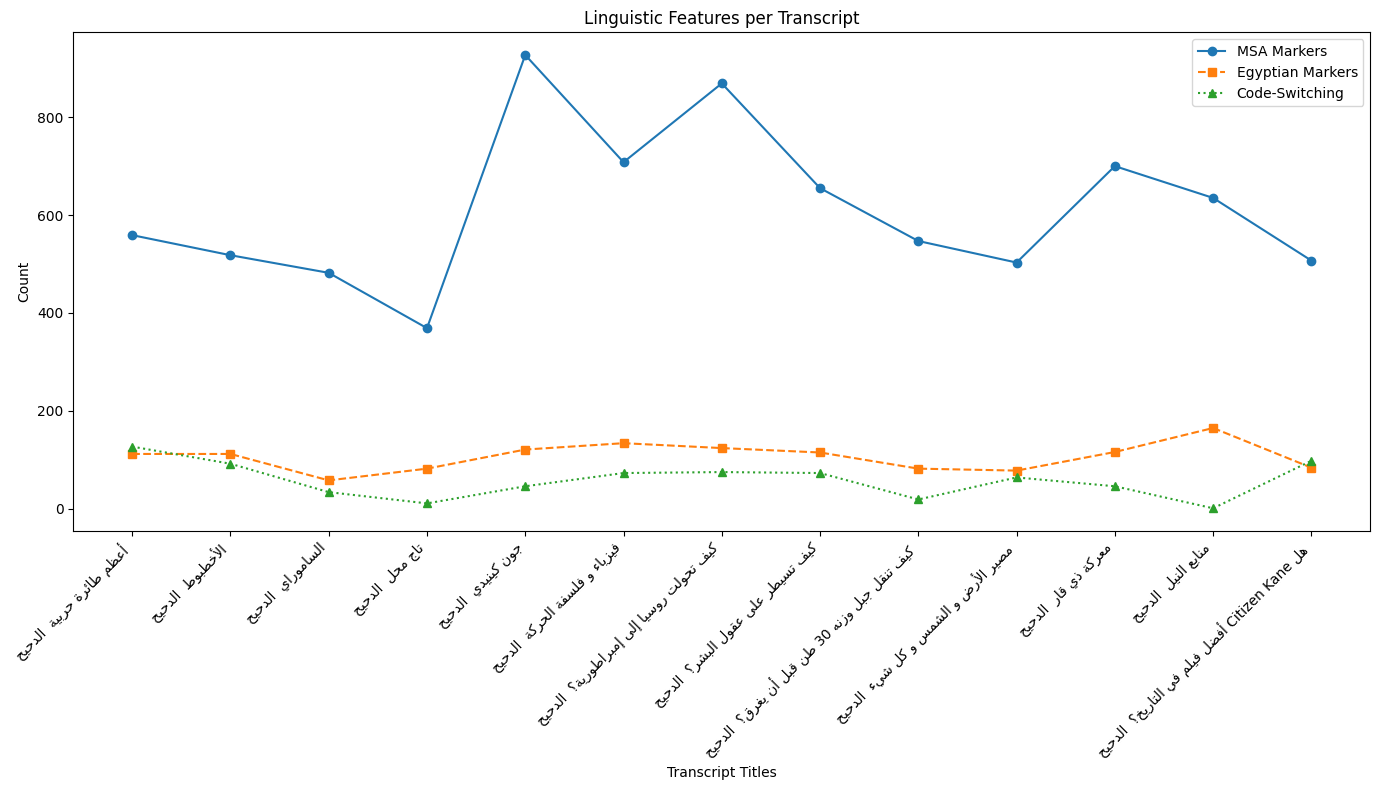

In [134]:
import re
import glob
from collections import Counter
import matplotlib.pyplot as plt
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# Define markers
msa_markers = {
    "الذي", "التي", "الذين", "اللاتي", "إلى", "عن", "في", "على", "مع", "من",
    "هذا", "هذه", "هؤلاء", "ذلك", "تلك", "أولئك",
    "و", "أو", "لكن", "بل", "ثم", "حتى", "إلا", "إذا", "لو", "إن",
    "كان", "كانت", "يكون", "تكون", "أصبح", "أصبحت", "أصبحنا", "أصبحتم", "أصبحوا",
    "يجب", "يجوز", "يُعتبر", "يُعد", "يُسمى", "يُشار", "يُشارك", "يُشاركون",
    "أيضاً", "أيضا", "أكثر", "أقل", "أولاً", "ثانياً", "ثالثاً", "أخيراً",
    "فقط", "حسب", "بسبب", "بعد", "قبل", "خلال", "أثناء",
    "الأمر", "الأمور", "الحالة", "الظروف", "النتيجة", "السبب", "الغرض",
    "المشكلة", "الحل", "القرار", "الرأي", "الرأي العام"
}

# msa_markers = {
#     "الذي", "التي", "الذين", "اللاتي", "إلى", "عن",
#     "هذا", "هذه", "هؤلاء", "ذلك", "تلك", "أولئك",
#     "لكن", "بل", "ثم", "حتى", "إلا",
#     "كانت", "يكون", "تكون", "أصبح", "أصبحت", "أصبحنا", "أصبحتم", "أصبحوا",
#     "يجب", "يجوز", "يُعتبر", "يُعد", "يُسمى", "يُشار", "يُشارك", "يُشاركون",
#     "أيضاً", "أيضا", "أكثر", "أقل", "أولاً", "ثانيا", "ثالثا", "أخيرا",
#     "فقط", "حسب", "بسبب", "خلال", "أثناء",
#     "الأمر", "الأمور", "الحالة", "الظروف", "النتيجة", "السبب", "الغرض",
#     "المشكلة", "الحل", "القرار", "الرأي", "الرأي العام","عزيزي", "عزيزتي", "سيد", "سيدة", "حضرة", "حضرات"
# }

egyptian_markers = {
    "إيه", "ليه", "مش", "عايز", "بتاع", "أوي", "هما", "ده", "فيه", "حاجة",
    "كده", "فعلاً", "هنا", "هت", "ليه", "إزاي"
}

# Get list of transcript files
transcript_files = glob.glob("data/Transcripts/*.txt")

# Prepare data lists
titles = []
msa_counts = []
egyptian_counts = []
switch_counts = []

for file_path in transcript_files:
    filename = file_path.split("\\")[-1].replace(".txt", "")  # Remove .txt extension
    titles.append(filename)
    
    with open(file_path, encoding="utf-8") as f:
        text = f.read()
    
    # Tokenize for markers
    tokens = re.findall(r"[\u0600-\u06FF]+", text.lower())
    msa_count = sum(1 for tok in tokens if tok in msa_markers)
    egyptian_count = sum(1 for tok in tokens if tok in egyptian_markers)
    
    msa_counts.append(msa_count)
    egyptian_counts.append(egyptian_count)
    
    # Code-switching count
    words = re.findall(r"\S+", text)
    prev_script = None
    switch_count = 0
    for word in words:
        if re.search(r"[A-Za-z]", word):
            current_script = "EN"
        elif re.search(r"[\u0600-\u06FF]", word):
            current_script = "AR"
        else:
            current_script = "OTHER"
        
        if prev_script == "AR" and current_script == "EN":
            switch_count += 1
        
        if current_script in ["AR", "EN"]:
            prev_script = current_script
    
    switch_counts.append(switch_count)

# Reshape titles for proper RTL display
reshaped_titles = [get_display(reshape(title)) for title in titles]

# Plot
plt.figure(figsize=(14, 8))
plt.plot(reshaped_titles, msa_counts, label='MSA Markers', marker='o', linestyle='-')
plt.plot(reshaped_titles, egyptian_counts, label='Egyptian Markers', marker='s', linestyle='--')
plt.plot(reshaped_titles, switch_counts, label='Code-Switching', marker='^', linestyle=':')
plt.xticks(rotation=45, ha='right')  # Rotate for readability, ha='right' for RTL
plt.title('Linguistic Features per Transcript')
plt.xlabel('Transcript Titles')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


##### filtering MSA markers & adding remarkable famous MSA words from episodes

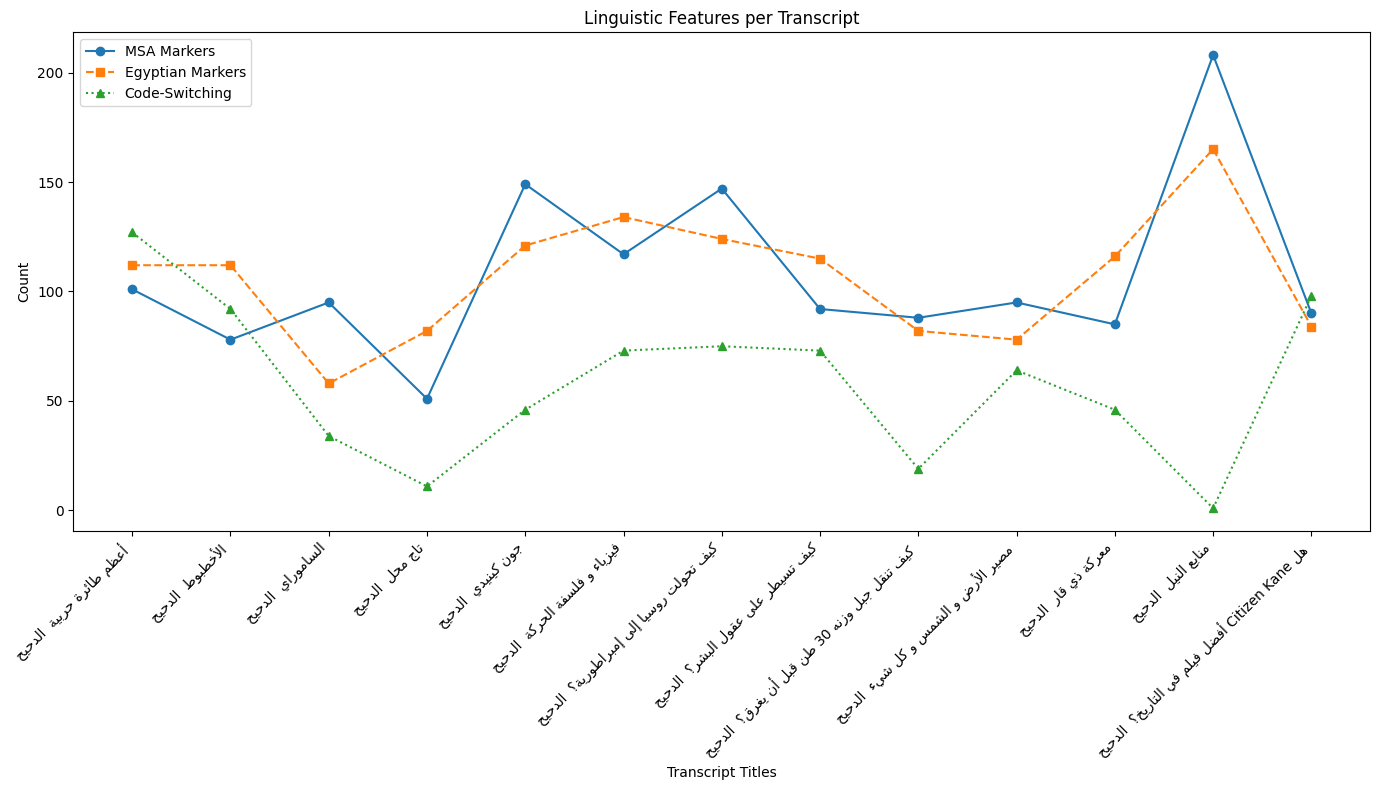

In [135]:
import re
import glob
from collections import Counter
import matplotlib.pyplot as plt
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# Define markers
# msa_markers = {
#     "الذي", "التي", "الذين", "اللاتي", "إلى", "عن", "في", "على", "مع", "من",
#     "هذا", "هذه", "هؤلاء", "ذلك", "تلك", "أولئك",
#     "و", "أو", "لكن", "بل", "ثم", "حتى", "إلا", "إذا", "لو", "إن",
#     "كان", "كانت", "يكون", "تكون", "أصبح", "أصبحت", "أصبحنا", "أصبحتم", "أصبحوا",
#     "يجب", "يجوز", "يُعتبر", "يُعد", "يُسمى", "يُشار", "يُشارك", "يُشاركون",
#     "أيضاً", "أيضا", "أكثر", "أقل", "أولاً", "ثانياً", "ثالثاً", "أخيراً",
#     "فقط", "حسب", "بسبب", "بعد", "قبل", "خلال", "أثناء",
#     "الأمر", "الأمور", "الحالة", "الظروف", "النتيجة", "السبب", "الغرض",
#     "المشكلة", "الحل", "القرار", "الرأي", "الرأي العام"
# }

msa_markers = {
    "الذي", "التي", "الذين", "اللاتي", "إلى", "عن",
    "هذا", "هذه", "هؤلاء", "ذلك", "تلك", "أولئك",
    "لكن", "بل", "ثم", "حتى", "إلا",
    "كانت", "يكون", "تكون", "أصبح", "أصبحت", "أصبحنا", "أصبحتم", "أصبحوا",
    "يجب", "يجوز", "يُعتبر", "يُعد", "يُسمى", "يُشار", "يُشارك", "يُشاركون",
    "أيضاً", "أيضا", "أكثر", "أقل", "أولاً", "ثانيا", "ثالثا", "أخيرا",
    "فقط", "حسب", "بسبب", "خلال", "أثناء",
    "الأمر", "الأمور", "الحالة", "الظروف", "النتيجة", "السبب", "الغرض",
    "المشكلة", "الحل", "القرار", "الرأي", "الرأي العام","عزيزي", "عزيزتي", "سيد", "سيدة", "حضرة", "حضرات"
}

egyptian_markers = {
    "إيه", "ليه", "مش", "عايز", "بتاع", "أوي", "هما", "ده", "فيه", "حاجة",
    "كده", "فعلاً", "هنا", "هت", "ليه", "إزاي"
}

# Get list of transcript files
transcript_files = glob.glob("data/Transcripts/*.txt")

# Prepare data lists
titles = []
msa_counts = []
egyptian_counts = []
switch_counts = []

for file_path in transcript_files:
    filename = file_path.split("\\")[-1].replace(".txt", "")  # Remove .txt extension
    titles.append(filename)
    
    with open(file_path, encoding="utf-8") as f:
        text = f.read()
    
    # Tokenize for markers
    tokens = re.findall(r"[\u0600-\u06FF]+", text.lower())
    msa_count = sum(1 for tok in tokens if tok in msa_markers)
    egyptian_count = sum(1 for tok in tokens if tok in egyptian_markers)
    
    msa_counts.append(msa_count)
    egyptian_counts.append(egyptian_count)
    
    # Code-switching count
    words = re.findall(r"\S+", text)
    prev_script = None
    switch_count = 0
    for word in words:
        if re.search(r"[A-Za-z]", word):
            current_script = "EN"
        elif re.search(r"[\u0600-\u06FF]", word):
            current_script = "AR"
        else:
            current_script = "OTHER"
        
        if prev_script == "AR" and current_script == "EN":
            switch_count += 1
        
        if current_script in ["AR", "EN"]:
            prev_script = current_script
    
    switch_counts.append(switch_count)

# Reshape titles for proper RTL display
reshaped_titles = [get_display(reshape(title)) for title in titles]

# Plot
plt.figure(figsize=(14, 8))
plt.plot(reshaped_titles, msa_counts, label='MSA Markers', marker='o', linestyle='-')
plt.plot(reshaped_titles, egyptian_counts, label='Egyptian Markers', marker='s', linestyle='--')
plt.plot(reshaped_titles, switch_counts, label='Code-Switching', marker='^', linestyle=':')
plt.xticks(rotation=45, ha='right')  # Rotate for readability, ha='right' for RTL
plt.title('Linguistic Features per Transcript')
plt.xlabel('Transcript Titles')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


### word frequency visualization before cleaning

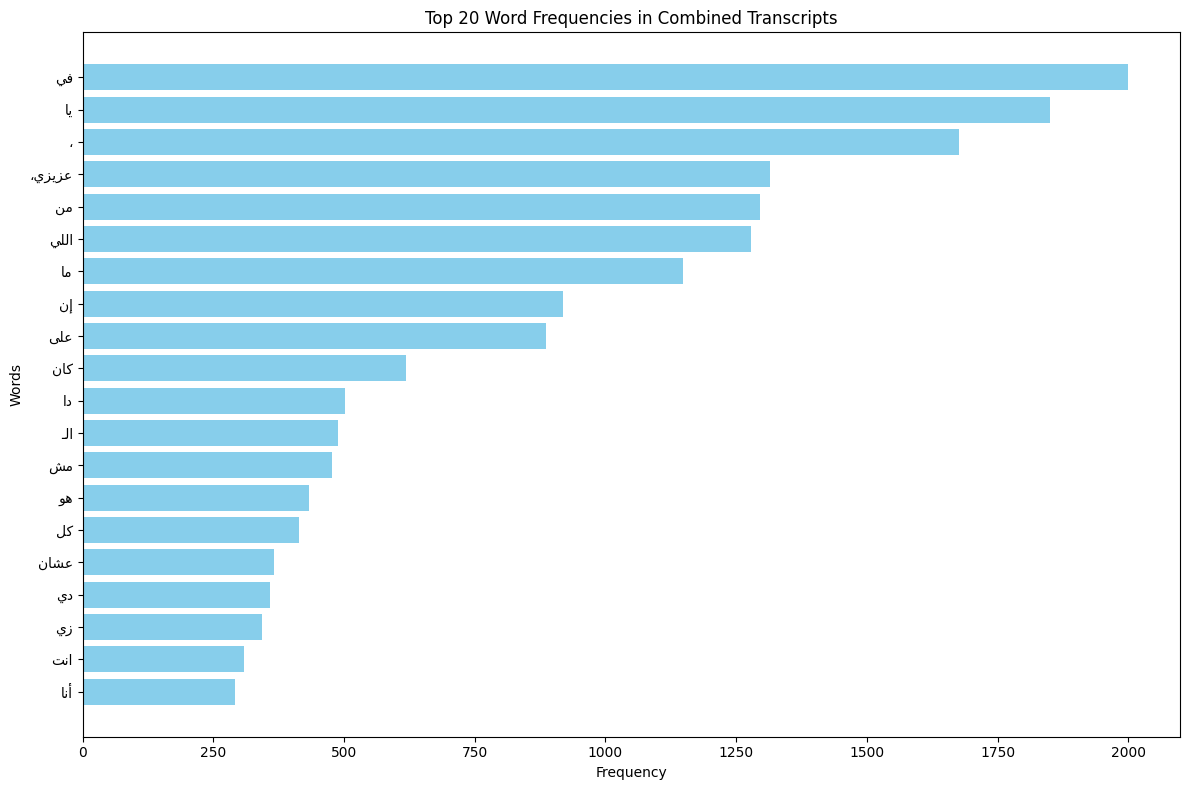

In [163]:
import re
import glob
from collections import Counter
import matplotlib.pyplot as plt
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# Get list of transcript files
transcript_files = glob.glob("data/Transcripts/*.txt")

# Combine all transcript texts
all_text = ""
for file_path in transcript_files:
    with open(file_path, encoding="utf-8") as f:
        all_text += f.read() + " "

# Tokenize (only Arabic-script tokens)
tokens = re.findall(r"[\u0600-\u06FF]+", all_text.lower())

# Count word frequencies
word_freq = Counter(tokens)

# Get top 20 most common words
top_words = word_freq.most_common(20)

# Prepare data for plotting
words, counts = zip(*top_words)

# Reshape words for proper RTL display
reshaped_words = [get_display(reshape(word)) for word in words]

# Plot
plt.figure(figsize=(12, 8))
plt.barh(reshaped_words, counts, color='skyblue')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top 20 Word Frequencies in Combined Transcripts')
plt.gca().invert_yaxis()  # Invert y-axis to have highest at top
plt.yticks(ha='right')  # Align y-tick labels to the right for RTL
plt.tight_layout()
plt.show()

## Data Preprocessing

In [136]:
df_train["question_length"] = df_train["question"].apply(len)
df_train["answer_length"] = df_train["answer"].apply(len)

print(df_train.describe())

       question_length  answer_length
count      3890.000000    3890.000000
mean         29.481234      27.937532
std           5.950017       8.209206
min          14.000000       3.000000
25%          25.000000      21.000000
50%          31.000000      28.000000
75%          33.000000      34.000000
max          38.000000      52.000000


### OLD and GOLD function

In [137]:
# from pathlib import Path
# from difflib import get_close_matches

# TRANSCRIPTS_DIR = Path("data/Transcripts")

# def normalize_arabic_text(text: str) -> str:
#     text = str(text).strip().lower()
#     # remove zero width characters
#     text = re.sub(r'[\u200B-\u200D\uFEFF]', '', text)
#     # remove Arabic diacritics
#     text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
#     # normalize common Arabic letter variants
#     text = re.sub(r"[إأآا]", "ا", text)
#     text = re.sub(r"ى", "ي", text)
#     text = re.sub(r"ة", "ه", text)
#     text = re.sub(r"گ", "ك", text)
#     text = text.replace("ـ", "")
#     return text

# def remove_timestamps(text):
#     return re.sub(r'\d+\.\d+:', '', text)

# def normalize_title(title: str) -> str:
#     t = normalize_arabic_text(title)
#     t = t.replace(".txt", "")
#     t = re.sub(r"\bالدحيح\b", "", t)
#     t = re.sub(r"\s+", " ", t).strip()
#     return t

# def tokenize_words(text: str):
#     # keep Arabic/English word tokens only
#     return re.findall(r"[\w]+", str(text), flags=re.UNICODE)

# def normalize_tokens(tokens):
#     normalized = []
#     for tok in tokens:
#         nt = normalize_arabic_text(tok)
#         nt = re.sub(r"[^\w]", "", nt, flags=re.UNICODE)
#         if nt:
#             normalized.append(nt)
#     return normalized

# def find_sublist_index(haystack, needle):
#     if not needle or len(needle) > len(haystack):
#         return -1
#     n = len(needle)
#     for i in range(len(haystack) - n + 1):
#         if haystack[i:i+n] == needle:
#             return i
#     return -1

# # Build transcript index keyed by normalized title
# transcript_index = {}
# for transcript_path in TRANSCRIPTS_DIR.glob("*.txt"):
#     raw_text = transcript_path.read_text(encoding="utf-8")
#     raw_text = remove_timestamps(raw_text)
#     original_tokens = tokenize_words(raw_text)
#     normalized_tokens = normalize_tokens(original_tokens)

#     key = normalize_title(transcript_path.stem)
#     transcript_index[key] = {
#         "path": transcript_path,
#         "original_tokens": original_tokens,
#         "normalized_tokens": normalized_tokens
#     }

# def match_transcript_key(video_title: str):
#     key = normalize_title(video_title)
#     if key in transcript_index:
#         return key
#     # fallback fuzzy match if title is slightly different
#     matches = get_close_matches(key, list(transcript_index.keys()), n=1, cutoff=0.55)
#     return matches[0] if matches else None

# def extract_context_from_row(row, window=20):
#     matched_key = match_transcript_key(row["video_title"])
#     if not matched_key:
#         return ""

#     answer_tokens = tokenize_words(str(row["answer"]))
#     answer_tokens_norm = normalize_tokens(answer_tokens)
#     if not answer_tokens_norm:
#         return ""

#     transcript = transcript_index[matched_key]
#     idx = find_sublist_index(transcript["normalized_tokens"], answer_tokens_norm)
#     if idx == -1:
#         return ""

#     start = max(0, idx - window)
#     end = min(len(transcript["original_tokens"]), idx + len(answer_tokens_norm) + window)
#     # keep context in original (non-normalized) transcript form
#     return " ".join(transcript["original_tokens"][start:end])

# # Add context column
# df_train["context"] = df_train.apply(extract_context_from_row, axis=1)

# # Optional quick quality check
# found_ratio = (df_train["context"].str.len() > 0).mean() * 100
# print(f"Context extracted for {found_ratio:.1f}% of rows")
# df_train[["video_title", "answer", "context"]].head()

### Clean And normalize Text Fields

In [138]:
def process_text_column(df, column_name):

    df[column_name] =df[column_name].apply(remove_stopwords_and_punctuation_from_text)
    df[column_name] =df[column_name].apply(normalize_text)
    return df

def remove_stopwords_and_punctuation_from_text(text):
    nltk_stop_words = set(stopwords.words('arabic'))


    # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
    punctuation = [
    "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
    ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
    "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
    ]
    for p in punctuation:
        text = text.replace(p, '')

    tokens = nltk.word_tokenize(text)

    filtered_tokens = [
        word for word in tokens 
        if word not in nltk_stop_words 
        and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
    # Join the tokens back into a string
    filtered_text = ' '.join(filtered_tokens)
    return filtered_text

def remove_timestamps(text):
    return re.sub(r'\d+\.\d+:', '', text)

def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    # text = re.sub("ؤ", "و", text)
    # text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [139]:
process_text_column(df_train, "question")
process_text_column(df_train, "answer")

# df_train.to_csv("output.csv", index=False, encoding="utf-8-sig")

,video_id,video_title,question_id,question,answer,difficulty,question_length,answer_length
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,الموضع النص,افتح موضوع جديد ميدو مش ناقص,Easy,31,39
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,الجمله المذكوره السياق,وبعد كدا هتنطفي كمان,Medium,33,25
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,صيغت العباره,ايوه,Easy,21,7
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,قيل الجزء,عشان كل حاجه بتنتهي,Medium,25,23
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,النص الحرفي المذكور الفقره,عشان الفيزيا بتقول كدا,Easy,37,25
...,...,...,...,...,...,...,...,...
3885,z2NGnjXG5uQ,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,z2NGnjXG5uQ_Q296,الموضع النص,تشارلز افتكر بطرس هرب المعركه,Medium,31,40
3886,z2NGnjXG5uQ,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,z2NGnjXG5uQ_Q297,الجمله المذكوره السياق,ويخش ياخد روسيا,Easy,33,18
3887,z2NGnjXG5uQ,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,z2NGnjXG5uQ_Q298,صيغت العباره,اخطر عنصر الاتحاد,Medium,21,23
3888,z2NGnjXG5uQ,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,z2NGnjXG5uQ_Q299,قيل الجزء,بولندا الخصم الصعب العنيف,Easy,25,29


In [ ]:
raw_vocab_df = pd.concat(
    [pd.read_csv(file_path) for file_path in glob.glob("data/QA/*.csv")],
    ignore_index=True
)

raw_texts = (
    raw_vocab_df["question"].astype(str)
    + " "
    + raw_vocab_df["answer"].astype(str)
)

vocab_before = set()
for text in raw_texts:
    vocab_before.update(nltk.word_tokenize(text))

normalized_texts = raw_texts.apply(remove_stopwords_and_punctuation_from_text).apply(normalize_text)

vocab_after = set()
for text in normalized_texts:
    vocab_after.update(text.split())

print("Vocabulary size before normalization:", len(vocab_before))
print("Vocabulary size after normalization:", len(vocab_after))

### Add Context Column

In [140]:
from difflib import get_close_matches


def add_context_column(df_train, transcripts_dir="data/Transcripts", window=20):

    # Load transcripts
    transcripts = {}

    files = glob.glob(os.path.join(transcripts_dir, "*.txt"))

    for file_path in files:

        file_name = os.path.basename(file_path).replace(".txt", "")

        with open(file_path, encoding="utf-8") as f:
            text = f.read()

        text = remove_timestamps(text)
        text = remove_stopwords_and_punctuation_from_text(text)
        text = normalize_text(text)

        transcripts[file_name] = text

    transcript_names = list(transcripts.keys())
    contexts = []


    # Iterate rows
    for _, row in df_train.iterrows():

        title = row["video_title"]
        answer = normalize_text(row["answer"])

        # find closest transcript name
        match = get_close_matches(title, transcript_names, n=1, cutoff=0.4)

        if not match:
            contexts.append("")
            continue

        transcript = transcripts[match[0]]

        idx = transcript.find(answer)

        if idx == -1:
            contexts.append("")
            continue

        before = transcript[:idx].split()
        after = transcript[idx + len(answer):].split()

        start = max(0, len(before) - window)

        context_words = before[start:] + answer.split() + after[:window]

        context = " ".join(context_words)

        contexts.append(context)


    # add column
    df_train["context"] = contexts

    return df_train


df_train = add_context_column(df_train)
df_train.head()

,video_id,video_title,question_id,question,answer,difficulty,question_length,answer_length,context
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,الموضع النص,افتح موضوع جديد ميدو مش ناقص,Easy,31,39,بابا بابا بابا احنا جينا ازاي لا دا السؤال بتا...
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,الجمله المذكوره السياق,وبعد كدا هتنطفي كمان,Medium,33,25,لا دا السؤال بتاع امبارح افتح موضوع جديد ميدو ...
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,صيغت العباره,ايوه,Easy,21,7,موضوع جديد ميدو مش ناقص طيب الشمس هتفضل منوره ...
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,قيل الجزء,عشان كل حاجه بتنتهي,Medium,25,23,ميدو مش ناقص طيب الشمس هتفضل منوره لحد امتي لح...
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,النص الحرفي المذكور الفقره,عشان الفيزيا بتقول كدا,Easy,37,25,هتفضل منوره لحد امتي لحد نهايه الكون وبعد كدا ...


### word frequency visualization after cleaning 

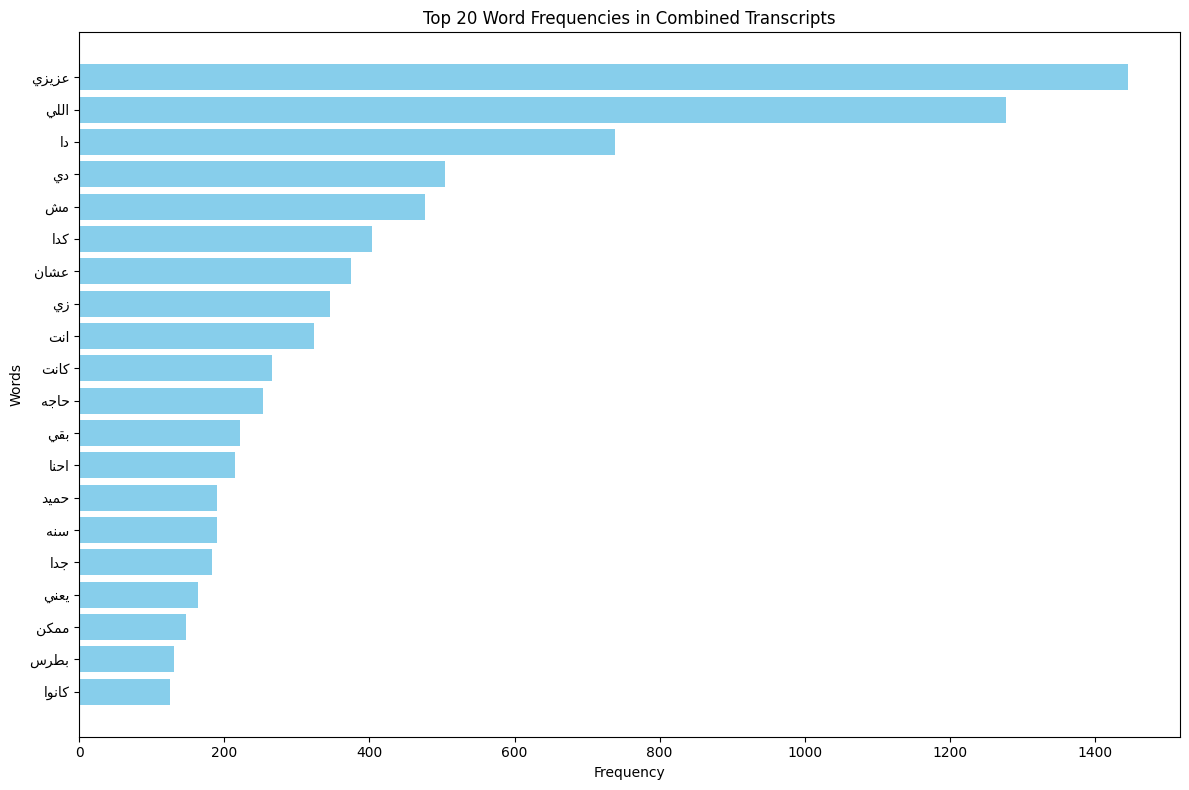

In [162]:
import re
import glob
from collections import Counter
import matplotlib.pyplot as plt
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# Get list of transcript files
transcript_files = glob.glob("data/Transcripts/*.txt")

# Combine all transcript texts
all_text = ""
for file_path in transcript_files:
    with open(file_path, encoding="utf-8") as f:
        all_text += f.read() + " "

# Clean the combined text
all_text = remove_timestamps(all_text)
all_text = remove_stopwords_and_punctuation_from_text(all_text)
all_text = normalize_text(all_text)

# Tokenize (only Arabic-script tokens)
tokens = re.findall(r"[\u0600-\u06FF]+", all_text.lower())

# Count word frequencies
word_freq = Counter(tokens)

# Get top 20 most common words
top_words = word_freq.most_common(20)

# Prepare data for plotting
words, counts = zip(*top_words)

# Reshape words for proper RTL display
reshaped_words = [get_display(reshape(word)) for word in words]

# Plot
plt.figure(figsize=(12, 8))
plt.barh(reshaped_words, counts, color='skyblue')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top 20 Word Frequencies in Combined Transcripts')
plt.gca().invert_yaxis()  # Invert y-axis to have highest at top
plt.yticks(ha='right')  # Align y-tick labels to the right for RTL
plt.tight_layout()
plt.show()

### Check answer and question length after preprocessing

In [141]:
df_train["answer_length"] = df_train["answer"].apply(len)
df_train.head()

,video_id,video_title,question_id,question,answer,difficulty,question_length,answer_length,context
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,الموضع النص,افتح موضوع جديد ميدو مش ناقص,Easy,31,28,بابا بابا بابا احنا جينا ازاي لا دا السؤال بتا...
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,الجمله المذكوره السياق,وبعد كدا هتنطفي كمان,Medium,33,20,لا دا السؤال بتاع امبارح افتح موضوع جديد ميدو ...
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,صيغت العباره,ايوه,Easy,21,4,موضوع جديد ميدو مش ناقص طيب الشمس هتفضل منوره ...
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,قيل الجزء,عشان كل حاجه بتنتهي,Medium,25,19,ميدو مش ناقص طيب الشمس هتفضل منوره لحد امتي لح...
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,النص الحرفي المذكور الفقره,عشان الفيزيا بتقول كدا,Easy,37,22,هتفضل منوره لحد امتي لحد نهايه الكون وبعد كدا ...


### Check on short answers

In [142]:
df_train[df_train["answer_length"] == 5]

,video_id,video_title,question_id,question,answer,difficulty,question_length,answer_length,context
59,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q060,النص الحرفي المذكور الفقره,متغير,Medium,37,5,يومين نجم الصوره طلعش نجم طبيعي اللي بينوروا ل...
160,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q161,الموضع النص,اسمها,Easy,31,5,الطبيعه تكره الفراغ دا معناه حميد معلش متلخبط ...
425,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q126,النص حول الجزئيه,كتابه,Medium,33,5,حياه موت خسرش واحده دا عزيزي الراجل اللي اخترع...
496,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q197,الجمله المذكوره الموضع,اتنين,Easy,33,5,العالم عندهم حاجات زي الساموراي كدا ناس متمرنه...
640,8rcY34IA-6I,الأخطبوط | الدحيح,8rcY34IA-6I_Q041,النص الفقره رقم 41,نخدره,Easy,37,5,نقول دا دا عبقري احنا عزيزي كنا بنتعامل الاخطب...
649,8rcY34IA-6I,الأخطبوط | الدحيح,8rcY34IA-6I_Q050,النص الفقره رقم 50,عزيزي,Medium,37,5,وطحينه لا خلاص هاقوم اسلقه حالا اخلص اعزائي ال...
667,8rcY34IA-6I,الأخطبوط | الدحيح,8rcY34IA-6I_Q068,النص الفقره رقم 68,متحرك,Medium,37,5,بالعكس دا نسبه البروتين الانواع بتوصل ل35 دا ط...
694,8rcY34IA-6I,الأخطبوط | الدحيح,8rcY34IA-6I_Q095,النص الفقره رقم 95,اسمها,Easy,37,5,تنفجر وقت قصير الكائنات ابتدا يبقي ليها هياكل ...
711,8rcY34IA-6I,الأخطبوط | الدحيح,8rcY34IA-6I_Q112,النص الفقره رقم 112,يقولك,Medium,38,5,زاهيه اوي انت غالبا كنت سام فالاخطبوط ممكن يلع...
715,8rcY34IA-6I,الأخطبوط | الدحيح,8rcY34IA-6I_Q116,النص الفقره رقم 116,اسمها,Medium,38,5,تنفجر وقت قصير الكائنات ابتدا يبقي ليها هياكل ...


### Remove short answers and Drop unrelated columns 

In [143]:
# remove rows with very short answers (likely to be noise) like df_train[df_train["answer_length"] < 6 ]

df_train = df_train[df_train["answer_length"] >= 6].reset_index(drop=True)

# drop unrelated columns to save memory
df_train = df_train.drop(columns=["video_id", "video_title", "question_id","difficulty", "question_length", "answer_length"])


### Analyze text after preprocessing

In [144]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3806 entries, 0 to 3805
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   question  3806 non-null   str  
 1   answer    3806 non-null   str  
 2   context   3806 non-null   str  
dtypes: str(3)
memory usage: 89.3 KB


In [145]:
df_train.head()

,question,answer,context
0,الموضع النص,افتح موضوع جديد ميدو مش ناقص,بابا بابا بابا احنا جينا ازاي لا دا السؤال بتا...
1,الجمله المذكوره السياق,وبعد كدا هتنطفي كمان,لا دا السؤال بتاع امبارح افتح موضوع جديد ميدو ...
2,قيل الجزء,عشان كل حاجه بتنتهي,ميدو مش ناقص طيب الشمس هتفضل منوره لحد امتي لح...
3,النص الحرفي المذكور الفقره,عشان الفيزيا بتقول كدا,هتفضل منوره لحد امتي لحد نهايه الكون وبعد كدا ...
4,الموضع النص,عشان الفيزيا رياضه تطبيقيه,نهايه الكون وبعد كدا هتنطفي كمان الكون هينتهي ...


In [146]:
all_words = " ".join(df_train["answer"].astype(str)).split()

freq = Counter(all_words)

for word, count in freq.most_common(50):
    print(f"{word}: {count}")

اللي: 410
دا: 114
عزيزي: 98
مش: 95
دي: 93
جدا: 92
زي: 92
عشان: 89
كدا: 75
احنا: 67
كانت: 67
انت: 63
حاجه: 61
تكساس: 61
ولايه: 60
الطياره: 60
العالم: 57
اسمها: 46
دلوقتي: 45
بشكل: 44
سنه: 44
الامريكي: 42
ممكن: 41
الله: 38
عادي: 34
مارتن: 34
ضوئيه: 33
النيل: 33
لانه: 33
الناس: 32
واقف: 32
اقدم: 32
صعب: 32
7: 32
لحد: 31
المعبد: 31
هتغير: 31
2011: 30
لحضرتك: 30
فخر: 30
الطيران: 30
لوكهيد: 30
هيجرب: 30
الرادار: 30
يلقطها: 30
لغات: 30
المقدم: 30
ايريك: 30
سميث: 30
واسع: 30


In [147]:
# Save the processed DataFrame to a new CSV file
# df_train.to_csv("output.csv", index=False, encoding="utf-8-sig")

In [148]:
# Save processed text
# output_path = "processed_transcript.txt"
# with open(output_path, "w", encoding="utf-8") as file:
#     file.write(processed_text)

## Tokenizer

In [149]:
tokenizer = Tokenizer(
    num_words=20000,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

### Chosen Tokenization Approach

We used a **word-level Keras Tokenizer** rather than character-level tokenization. This choice is appropriate because the dataset is made of natural-language Arabic questions, contexts, and answers, where meaning is carried more clearly by words than by individual characters.

The tokenizer was configured with `char_level=False`, so each token represents a full word. This keeps the representation more interpretable and better aligned with the earlier cleaning steps, where punctuation, English fragments, tashkeel, and Arabic letter variants were normalized before tokenization.

We also set `num_words=20000` to keep only the most frequent words in the vocabulary. This reduces sparsity and prevents very rare words from making the token space unnecessarily large. In addition, `oov_token="<OOV>"` ensures that unseen words at inference time are mapped to a known token instead of being dropped completely.

The tokenizer was fitted on the **input side** using `question + context`, because those are the main text sources the model needs to understand. After fitting, both the input text and the answers were converted into integer sequences. This allows the model to work with fixed numeric representations instead of raw text.

Overall, this approach was chosen because it is simple, efficient, and suitable for a cleaned Arabic QA dataset. It preserves useful word-level meaning while controlling vocabulary size and handling unseen tokens safely.

In [150]:
# fit on data input to tokenizer
all_texts = df_train['question'] + ' ' + df_train['context'] # optionally include answers in tokenizer fit
tokenizer.fit_on_texts(all_texts)
input_sequences = tokenizer.texts_to_sequences(df_train['question'] + ' ' + df_train['context'])

# fit on output
answer_sequences = tokenizer.texts_to_sequences(df_train['answer'])

In [151]:
# use this to get insight on the Tokenizer
vocab_list = tokenizer.word_index

In [152]:
lengths = [len(seq) for seq in input_sequences]
print("input_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

lengths = [len(seq) for seq in answer_sequences]
print("answer_sequences lengths:")
print("max:", np.max(lengths))
print("min:", np.min(lengths))
print("95 percentile:", np.percentile(lengths,95))
print("90 percentile:", np.percentile(lengths,90))

input_sequences lengths:
max: 53
min: 27
95 percentile: 49.0
90 percentile: 49.0
answer_sequences lengths:
max: 9
min: 1
95 percentile: 6.0
90 percentile: 6.0


In [153]:
max_length_input = 55
max_length_output = 10

### Before padding visualizations

Sequence lengths — min: 27, max: 53, mean: 46.5, median: 47.0
% sequences <= max_length (55): 100.0%


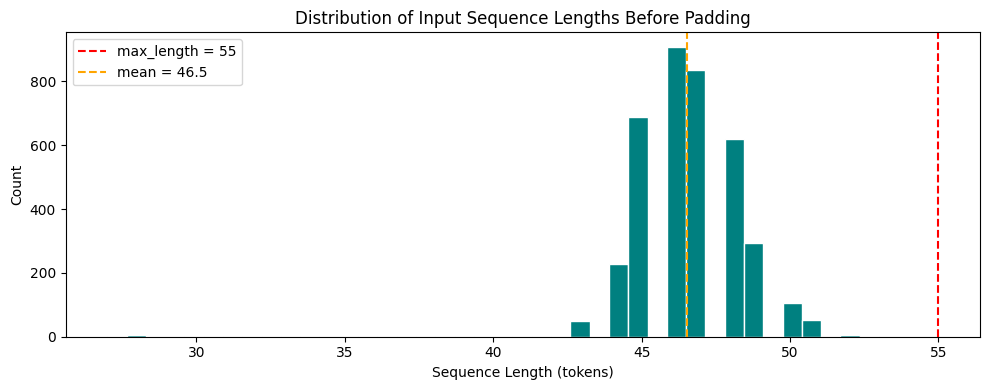

In [154]:
import numpy as np

# --- 3. Sequence length distribution (before padding) ---
seq_lengths = [len(s) for s in input_sequences]


print(f"Sequence lengths — min: {min(seq_lengths)}, max: {max(seq_lengths)}, "
      f"mean: {np.mean(seq_lengths):.1f}, median: {np.median(seq_lengths):.1f}")
print(f"% sequences <= max_length ({max_length_input}): "
      f"{100 * np.mean(np.array(seq_lengths) <= max_length_input):.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=40, color='teal', edgecolor='white')
ax.axvline(max_length_input, color='red', linestyle='--', label=f'max_length = {max_length_input}')
ax.axvline(np.mean(seq_lengths), color='orange', linestyle='--',
           label=f'mean = {np.mean(seq_lengths):.1f}')
ax.set_xlabel('Sequence Length (tokens)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Input Sequence Lengths Before Padding')
ax.legend()
plt.tight_layout()
plt.show()


Sequence lengths — min: 1, max: 9, mean: 3.9, median: 4.0
% sequences <= max_length (55): 100.0%


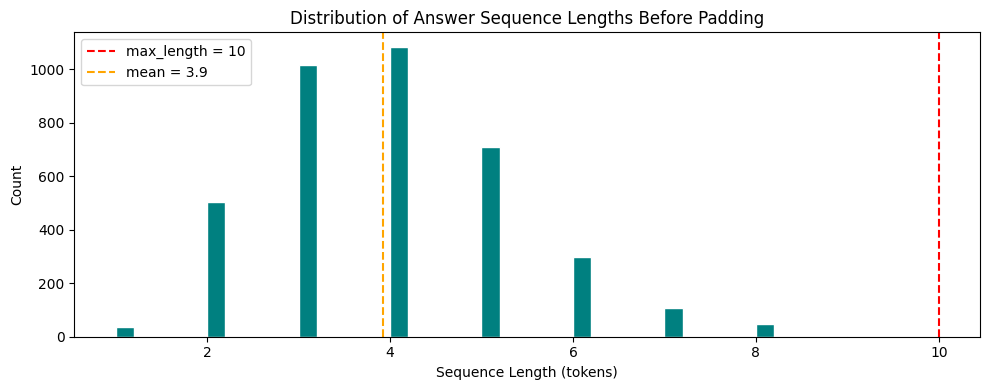

In [155]:
import numpy as np

# --- 3. Sequence length distribution (before padding) ---
seq_lengths = [len(s) for s in answer_sequences]

print(f"Sequence lengths — min: {min(seq_lengths)}, max: {max(seq_lengths)}, "
      f"mean: {np.mean(seq_lengths):.1f}, median: {np.median(seq_lengths):.1f}")
print(f"% sequences <= max_length ({max_length_input}): "
      f"{100 * np.mean(np.array(seq_lengths) <= max_length_input):.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lengths, bins=40, color='teal', edgecolor='white')
ax.axvline(max_length_output, color='red', linestyle='--', label=f'max_length = {max_length_output}')
ax.axvline(np.mean(seq_lengths), color='orange', linestyle='--',
           label=f'mean = {np.mean(seq_lengths):.1f}')
ax.set_xlabel('Sequence Length (tokens)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Answer Sequence Lengths Before Padding')
ax.legend()
plt.tight_layout()
plt.show()


### Padding

In [156]:
# # Padding
trunc_type='post'
padding_type='post'


train_input_padded = pad_sequences(
    input_sequences,
    maxlen=max_length_input,
    padding=padding_type,
    truncating=trunc_type
)

train_output_padded = pad_sequences(
    answer_sequences,
    maxlen=max_length_output,
    padding=padding_type,
    truncating=trunc_type
)

### After padding visualizations

Padded matrix shape:  (3806, 55)
Zero (pad) tokens:    15.4% of all positions


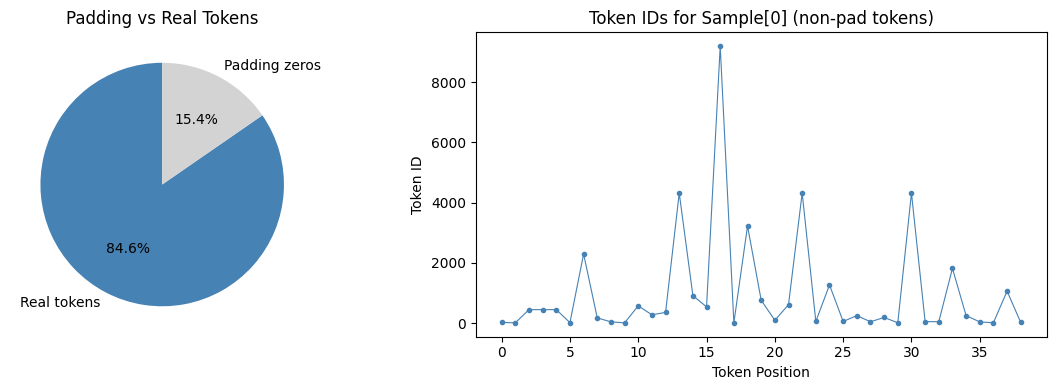


First 20 decoded tokens of sample[0]:
الموضع النص بابا بابا بابا احنا جينا ازاي لا دا السؤال بتاع امبارح افتح موضوع جديد ميدو مش ناقص طيب


In [157]:
# --- 4. Padding zero-ratio + sample decode ---
zero_ratio = (train_input_padded == 0).sum() / train_input_padded.size
print(f"Padded matrix shape:  {train_input_padded.shape}")
print(f"Zero (pad) tokens:    {zero_ratio*100:.1f}% of all positions")

# Pie chart: padding vs real tokens  |  Line chart: token IDs of first sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [1 - zero_ratio, zero_ratio],
    labels=['Real tokens', 'Padding zeros'],
    autopct='%1.1f%%',
    colors=['steelblue', 'lightgray'],
    startangle=90
)
axes[0].set_title('Padding vs Real Tokens')

sample_seq = train_input_padded[0]
non_pad = sample_seq[sample_seq != 0]
axes[1].plot(range(len(non_pad)), non_pad, marker='o', markersize=3,
             linewidth=0.8, color='steelblue')
axes[1].set_xlabel('Token Position')
axes[1].set_ylabel('Token ID')
axes[1].set_title('Token IDs for Sample[0] (non-pad tokens)')

plt.tight_layout()
plt.show()

# Decode sample back to words
reverse_vocab = {v: k for k, v in vocab_list.items()}
decoded = [reverse_vocab.get(int(t), '<OOV>') for t in non_pad[:20]]
print("\nFirst 20 decoded tokens of sample[0]:")
print(' '.join(decoded))


Padded matrix shape:  (3806, 10)
Zero (pad) tokens:    60.8% of all positions


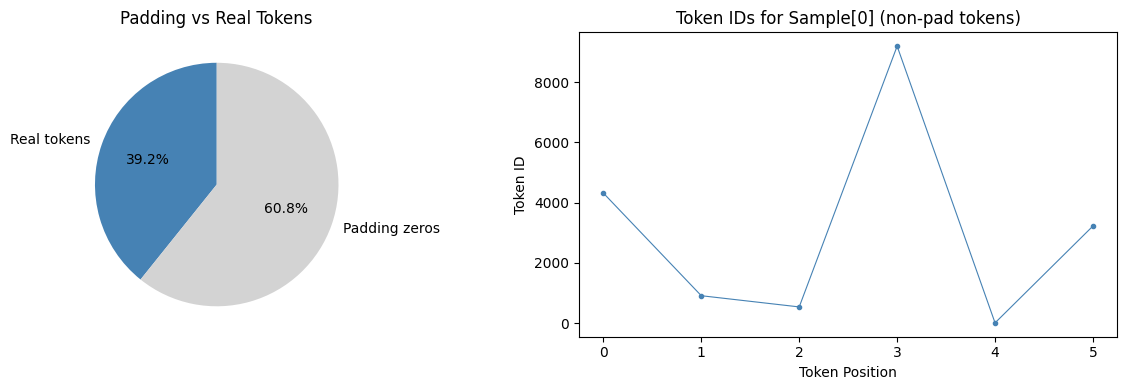


First 20 decoded tokens of sample[0]:
افتح موضوع جديد ميدو مش ناقص


In [158]:
# --- 4. Padding zero-ratio + sample decode ---
zero_ratio = (train_output_padded == 0).sum() / train_output_padded.size
print(f"Padded matrix shape:  {train_output_padded.shape}")
print(f"Zero (pad) tokens:    {zero_ratio*100:.1f}% of all positions")

# Pie chart: padding vs real tokens  |  Line chart: token IDs of first sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    [1 - zero_ratio, zero_ratio],
    labels=['Real tokens', 'Padding zeros'],
    autopct='%1.1f%%',
    colors=['steelblue', 'lightgray'],
    startangle=90
)
axes[0].set_title('Padding vs Real Tokens')

sample_seq = train_output_padded[0]
non_pad = sample_seq[sample_seq != 0]
axes[1].plot(range(len(non_pad)), non_pad, marker='o', markersize=3,
             linewidth=0.8, color='steelblue')
axes[1].set_xlabel('Token Position')
axes[1].set_ylabel('Token ID')
axes[1].set_title('Token IDs for Sample[0] (non-pad tokens)')

plt.tight_layout()
plt.show()

# Decode sample back to words
reverse_vocab = {v: k for k, v in vocab_list.items()}
decoded = [reverse_vocab.get(int(t), '<OOV>') for t in non_pad[:20]]
print("\nFirst 20 decoded tokens of sample[0]:")
print(' '.join(decoded))

## Model Parameters

In [159]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    input_sequences,
    answer_sequences,
    test_size=0.2,
    random_state=42
)